In [21]:
pip install numpy matplotlib


[notice] A new release of pip available: 22.2.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math

In [23]:
def uniform_numbers(a, b, n):
    return [random.uniform(a, b) for _ in range(n)]

def gaussian_num(mu, sigma, n):
    samples = []
    while len(samples) < n:
        u1 = random.uniform(-1, 1)
        u2 = random.uniform(-1, 1)
        s = u1**2 + u2**2
        if 0 < s < 1:
            k = math.sqrt(-2 * math.log(s) / s)
            x = u1 * k
            y = u2 * k
            samples.append(mu + sigma * x)
            if len(samples) < n:
                samples.append(mu + sigma * y)
    return samples[:n]

In [44]:
n = 500
sigma = 1
mu1, mu2 = 2, 3
mu_vec = np.array([mu1, mu2]) 

D1 = gaussian_num(mu1, sigma, n)  
D2 = gaussian_num(mu2, sigma, n)

In [25]:
X = np.column_stack([D1, D2])  
print(f"X shape: {X.shape}")

X shape: (500, 2)


In [26]:
cov_mat = np.cov(X, rowvar=False)             

eigvals, eigvecs = np.linalg.eigh(cov_mat)    
order = np.argsort(eigvals)[::-1]  
eigvals = eigvals[order]              
eigvecs = eigvecs[:, order]

print("True covariance C = sigma^2 * I =\n", sigma * np.eye(2))
print("Estimated covariance matrix =\n", cov_mat)
print("\nEstimated eigenvalues:", eigvals)
print("Estimated eigenvectors (columns):\n", eigvecs)

True covariance C = sigma^2 * I =
 [[1. 0.]
 [0. 1.]]
Estimated covariance matrix =
 [[1.11599582 0.02029177]
 [0.02029177 0.92853858]]

Estimated eigenvalues: [1.1181672 0.9263672]
Estimated eigenvectors (columns):
 [[-0.99432335  0.10640052]
 [-0.10640052 -0.99432335]]


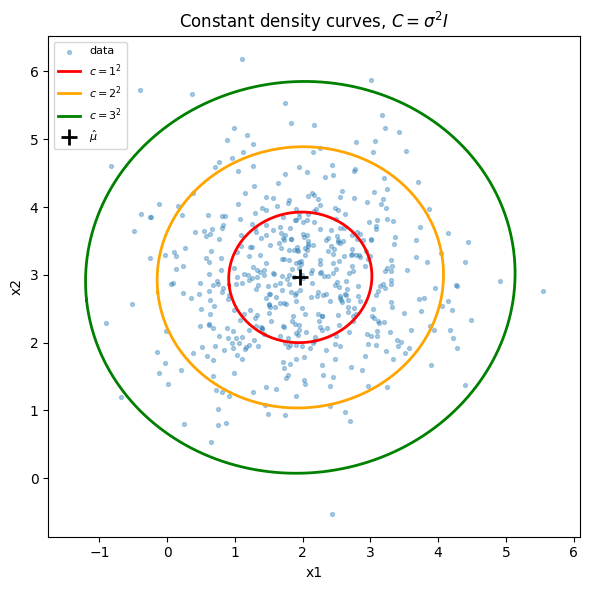

In [39]:
Sigma_inv = np.linalg.inv(cov_mat)
mu_hat = X.mean(axis=0)

def ellipse_points(mu, eigvals, eigvecs, c=1.0, n_pts=200):
    theta = np.linspace(0, 2*np.pi, n_pts)
    circle = np.vstack([np.cos(theta), np.sin(theta)])
    scale = np.diag(np.sqrt(eigvals))
    pts = mu.reshape(2, 1) + c * (eigvecs @ scale @ circle)
    return pts

c_values = [1, 2, 3]              
colors = ['r', 'orange', 'g']    

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(X[:, 0], X[:, 1], s=8, alpha=0.35, label="data")

for c, color in zip(c_values, colors):
    curve = ellipse_points(mu_hat, eigvals, eigvecs, c=c)
    ax.plot(curve[0], curve[1], color=color, linewidth=2,
            label=rf"$c={c}^2$")

ax.plot(mu_hat[0], mu_hat[1], 'k+', markersize=12, mew=2, label=r"$\hat{\mu}$")
ax.set_xlabel('x1'); ax.set_ylabel('x2')
ax.set_title('Constant density curves, $C = \sigma^2 I$')
ax.axis('equal'); ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

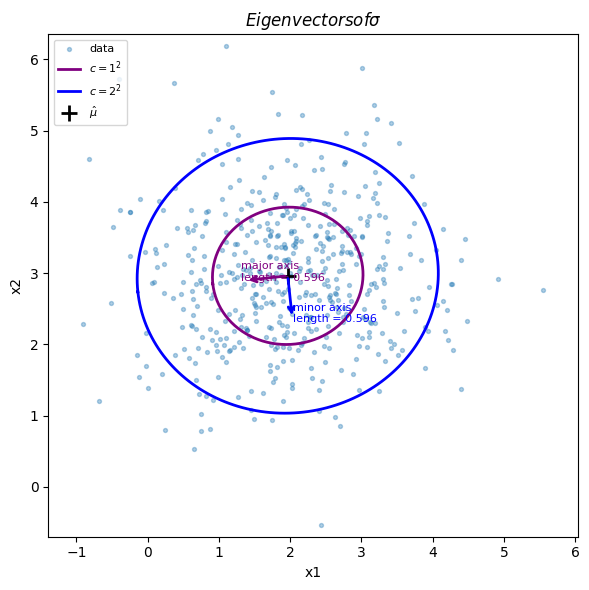

Major axis length (sqrt of largest eigenvalue):  1.0574
Minor axis length (sqrt of smallest eigenvalue): 0.9625


In [ ]:
mu_hat = X.mean(axis=0)


fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(X[:, 0], X[:, 1], s=8, alpha=0.35, label="data")

for c, color in zip(c_values, colors):
    curve = ellipse_points(mu_hat, eigvals, eigvecs, c=c)
    ax.plot(curve[0], curve[1], color=color, linewidth=2,
            label=rf"$c={c}^2$")

ax.plot(mu_hat[0], mu_hat[1], 'k+', markersize=12, mew=2, label=r"$\hat{\mu}$")

colors = ['purple', 'b']
axis_names = ['major axis', 'minor axis']   
for i in range(2):  # axis length at c = 1
    vec = eigvecs[:, i] * length
    ax.annotate('', xy=mu_hat + vec, xytext=mu_hat,
                arrowprops=dict(arrowstyle='->', color=colors[i], lw=2))
    ax.text(*(mu_hat + vec * 1.1), f"{axis_names[i]}\nlength = {length:.3f}",
            color=colors[i], fontsize=8)

ax.set_xlabel('x1'); ax.set_ylabel('x2')
ax.set_title(r"$Eigenvectors of sigma$")
ax.axis('equal'); ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

print(f"Major axis length (sqrt of largest eigenvalue):  {np.sqrt(eigvals[0]):.4f}")
print(f"Minor axis length (sqrt of smallest eigenvalue): {np.sqrt(eigvals[1]):.4f}")

In [42]:
true_eigvals = np.linalg.eigvalsh(sigma * np.eye(2))   # both equal to sigma^2 = 1

abs_diff = np.abs(eigvals - true_eigvals)
ratio = eigvals[0] / eigvals[1]     # eigvals sorted descending: eigvals[0] = largest

print(f"True eigenvalues (from C = sigma^2 I):  {true_eigvals}")
print(f"Estimated eigenvalues (from data):      {eigvals}")
print(f"Absolute difference:                    {abs_diff}")
print(f"Ratio largest/smallest (estimated):     {ratio:.4f}")

if ratio < 1.15:
    print("This ratio is close to 1, consistent with the isotropic covariance C = sigma^2 I "
          "used to generate the data, so the constant density curve is close to circular.")
else:
    print("This ratio deviates noticeably from 1, even though the true covariance is isotropic. "
          "This is attributable to sampling variability in a finite dataset rather than to any "
          "actual anisotropy in C, since the sample covariance only approximates the population "
          "covariance. Increasing N should bring this ratio closer to 1.")


True eigenvalues (from C = sigma^2 I):  [1. 1.]
Estimated eigenvalues (from data):      [1.1181672 0.9263672]
Absolute difference:                    [0.1181672 0.0736328]
Ratio largest/smallest (estimated):     1.2070
This ratio deviates noticeably from 1, even though the true covariance is isotropic. This is attributable to sampling variability in a finite dataset rather than to any actual anisotropy in C, since the sample covariance only approximates the population covariance. Increasing N should bring this ratio closer to 1.


Problem 2 
Diagonal Convariance Matrix

In [45]:

s11, s22 = 4.0, 0.25      

rootofs = np.diag([np.sqrt(s11), np.sqrt(s22)])  

Y = mu_vec + (X - mu_vec) @ rootofs.T 
print("Target covariance C =\n", np.diag([s11, s22]))
print(f"Y shape: {Y.shape}")
print(f"Estimated mean of Y: {Y.mean(axis=0)}  (target: {mu_vec})")

Target covariance C =
 [[4.   0.  ]
 [0.   0.25]]
Y shape: (500, 2)
Estimated mean of Y: [1.93135646 2.98095532]  (target: [2 3])


In [48]:
cov_mat_Y = np.cov(Y, rowvar=False)
eigvals_Y, eigvecs_Y = np.linalg.eigh(cov_mat_Y)
order = np.argsort(eigvals_Y)[::-1]
eigvals_Y = eigvals_Y[order]
eigvecs_Y = eigvecs_Y[:, order]

print("Estimated covariance matrix of Y =\n", cov_mat_Y)
print("Estimated eigenvalues:", eigvals_Y)
print("Estimated eigenvectors (columns):\n", eigvecs_Y)

Estimated covariance matrix of Y =
 [[4.46398328 0.02029177]
 [0.02029177 0.23213465]]
Estimated eigenvalues: [4.46408058 0.23203735]
Estimated eigenvectors (columns):
 [[-0.9999885   0.00479485]
 [-0.00479485 -0.9999885 ]]


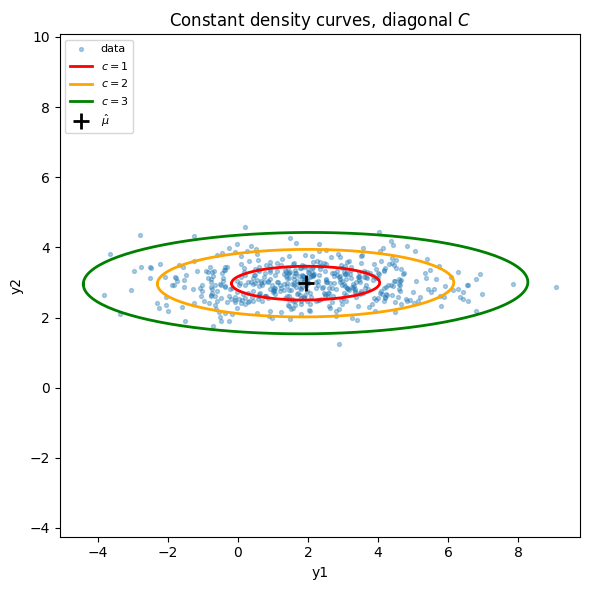

In [49]:
mu_hat_Y = Y.mean(axis=0)
c_values = [1, 2, 3]
colors = ['r', 'orange', 'g']

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(Y[:, 0], Y[:, 1], s=8, alpha=0.35, label="data")
for c, color in zip(c_values, colors):
    curve = ellipse_points(mu_hat_Y, eigvals_Y, eigvecs_Y, c=c)
    ax.plot(curve[0], curve[1], color=color, linewidth=2, label=rf"$c={c}$")
ax.plot(mu_hat_Y[0], mu_hat_Y[1], 'k+', markersize=12, mew=2, label=r"$\hat{\mu}$")
ax.set_xlabel('y1'); ax.set_ylabel('y2')
ax.set_title('Constant density curves, diagonal $C$')
ax.axis('equal'); ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

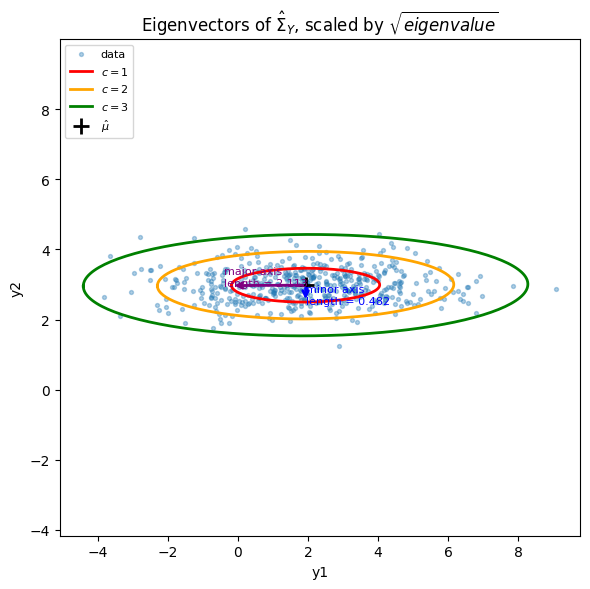

Major axis length (sqrt of largest eigenvalue):  2.1128
Minor axis length (sqrt of smallest eigenvalue): 0.4817


In [50]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(Y[:, 0], Y[:, 1], s=8, alpha=0.35, label="data")
for c, color in zip(c_values, colors):
    curve = ellipse_points(mu_hat_Y, eigvals_Y, eigvecs_Y, c=c)
    ax.plot(curve[0], curve[1], color=color, linewidth=2, label=rf"$c={c}$")
ax.plot(mu_hat_Y[0], mu_hat_Y[1], 'k+', markersize=12, mew=2, label=r"$\hat{\mu}$")

axis_colors = ['purple', 'b']
axis_names = ['major axis', 'minor axis']
for i in range(2):
    length = np.sqrt(eigvals_Y[i])         
    vec = eigvecs_Y[:, i] * length
    ax.annotate('', xy=mu_hat_Y + vec, xytext=mu_hat_Y,
                arrowprops=dict(arrowstyle='->', color=axis_colors[i], lw=2))
    ax.text(*(mu_hat_Y + vec * 1.1), f"{axis_names[i]}\nlength = {length:.3f}",
            color=axis_colors[i], fontsize=8)

ax.set_xlabel('y1'); ax.set_ylabel('y2')
ax.set_title(r'Eigenvectors of $\hat{\Sigma}_Y$, scaled by $\sqrt{eigenvalue}$')
ax.axis('equal'); ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

print(f"Major axis length (sqrt of largest eigenvalue):  {np.sqrt(eigvals_Y[0]):.4f}")
print(f"Minor axis length (sqrt of smallest eigenvalue): {np.sqrt(eigvals_Y[1]):.4f}")

In [51]:
true_eigvals_Y = np.linalg.eigvalsh(np.diag([s11, s22]))
order_true = np.argsort(true_eigvals_Y)[::-1]
true_eigvals_Y = true_eigvals_Y[order_true]

abs_diff = np.abs(eigvals_Y - true_eigvals_Y)
ratio_est = eigvals_Y[0] / eigvals_Y[1]
ratio_true = true_eigvals_Y[0] / true_eigvals_Y[1]

print(f"True eigenvalues (from diagonal C):     {true_eigvals_Y}")
print(f"Estimated eigenvalues (from data):      {eigvals_Y}")
print(f"Absolute difference:                    {abs_diff}")
print(f"Ratio largest/smallest (true):           {ratio_true:.4f}")
print(f"Ratio largest/smallest (estimated):      {ratio_est:.4f}")

if abs(ratio_est - ratio_true) < 0.3:
    print("The estimated ratio is close to the true ratio, confirming that the ellipse elongation "
          "seen in the plot matches the intended anisotropic covariance C.")
else:
    print("The estimated ratio deviates from the true ratio; this is attributable to sampling "
          "variability in a finite dataset. Increasing N should bring it closer to the true ratio.")

True eigenvalues (from diagonal C):     [4.   0.25]
Estimated eigenvalues (from data):      [4.46408058 0.23203735]
Absolute difference:                    [0.46408058 0.01796265]
Ratio largest/smallest (true):           16.0000
Ratio largest/smallest (estimated):      19.2386
The estimated ratio deviates from the true ratio; this is attributable to sampling variability in a finite dataset. Increasing N should bring it closer to the true ratio.


Problem 3 
Full Convariance Matrix

In [63]:
eigvals_C, eigvecs_C = np.linalg.eigh(C)
Sigma_half = eigvecs_C @ np.diag(np.sqrt(eigvals_C)) @ eigvecs_C.T

Y = mu_vec + (X - mu_vec) @ Sigma_half.T   # overwrite Y with data generated from full C

print("Target covariance C =\n", C)
print("Sigma^(1/2) =\n", Sigma_half)
print("Check: Sigma_half @ Sigma_half =\n", Sigma_half @ Sigma_half, " (should match C)")
print(f"\nY shape: {Y.shape}")
print(f"Estimated mean of Y: {Y.mean(axis=0)}  (target: {mu_vec})")

Target covariance C =
 [[4.  1.5]
 [1.5 1. ]]
Sigma^(1/2) =
 [[1.92502439 0.54247681]
 [0.54247681 0.84007078]]
Check: Sigma_half @ Sigma_half =
 [[4.  1.5]
 [1.5 1. ]]  (should match C)

Y shape: (500, 2)
Estimated mean of Y: [1.91326716 2.94938348]  (target: [2 3])


In [64]:
sigma11_sq, sigma22_sq = 4.0, 1.0
sigma12 = 1.5

C = np.array([[sigma11_sq, sigma12],
              [sigma12,    sigma22_sq]])

In [65]:
cov_mat_Y = np.cov(Y, rowvar=False)
eigvals_Y, eigvecs_Y = np.linalg.eigh(cov_mat_Y)
order = np.argsort(eigvals_Y)[::-1]
eigvals_Y = eigvals_Y[order]
eigvecs_Y = eigvecs_Y[:, order]

print("Estimated covariance matrix of Y =\n", cov_mat_Y)
print("Estimated eigenvalues:", eigvals_Y)
print("Estimated eigenvectors (columns):\n", eigvecs_Y)


Estimated covariance matrix of Y =
 [[4.45119879 1.62735238]
 [1.62735238 1.00219839]]
Estimated eigenvalues: [5.09781156 0.35558562]
Estimated eigenvectors (columns):
 [[-0.92932655  0.36925894]
 [-0.36925894 -0.92932655]]


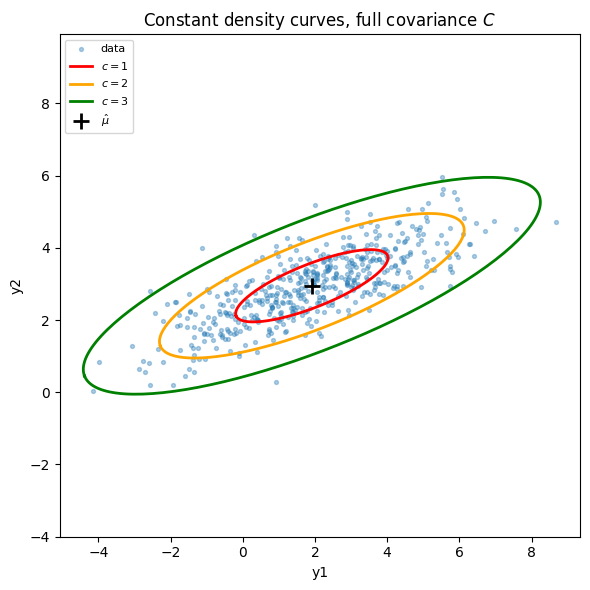

In [66]:
mu_hat_Y = Y.mean(axis=0)
c_values = [1, 2, 3]
colors = ['r', 'orange', 'g']

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(Y[:, 0], Y[:, 1], s=8, alpha=0.35, label="data")
for c, color in zip(c_values, colors):
    curve = ellipse_points(mu_hat_Y, eigvals_Y, eigvecs_Y, c=c)
    ax.plot(curve[0], curve[1], color=color, linewidth=2, label=rf"$c={c}$")
ax.plot(mu_hat_Y[0], mu_hat_Y[1], 'k+', markersize=12, mew=2, label=r"$\hat{\mu}$")
ax.set_xlabel('y1'); ax.set_ylabel('y2')
ax.set_title('Constant density curves, full covariance $C$')
ax.axis('equal'); ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

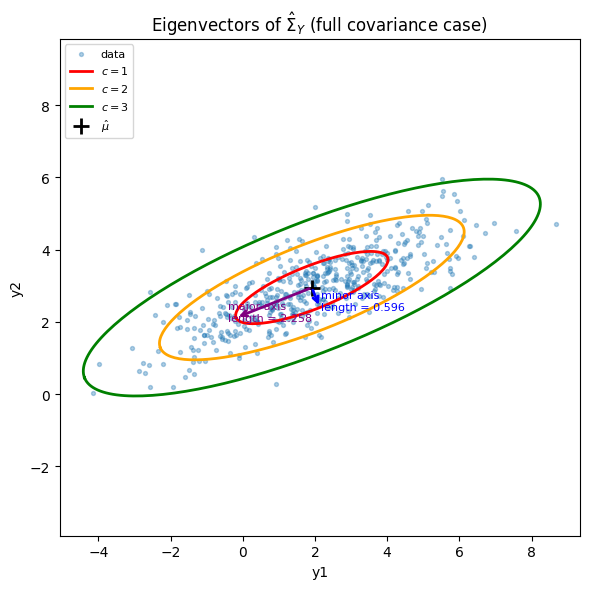

In [67]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(Y[:, 0], Y[:, 1], s=8, alpha=0.35, label="data")
for c, color in zip(c_values, colors):
    curve = ellipse_points(mu_hat_Y, eigvals_Y, eigvecs_Y, c=c)
    ax.plot(curve[0], curve[1], color=color, linewidth=2, label=rf"$c={c}$")
ax.plot(mu_hat_Y[0], mu_hat_Y[1], 'k+', markersize=12, mew=2, label=r"$\hat{\mu}$")

axis_colors = ['purple', 'b']
axis_names = ['major axis', 'minor axis']
for i in range(2):
    length = np.sqrt(eigvals_Y[i])
    vec = eigvecs_Y[:, i] * length
    ax.annotate('', xy=mu_hat_Y + vec, xytext=mu_hat_Y,
                arrowprops=dict(arrowstyle='->', color=axis_colors[i], lw=2))
    ax.text(*(mu_hat_Y + vec * 1.1), f"{axis_names[i]}\nlength = {length:.3f}",
            color=axis_colors[i], fontsize=8)

ax.set_xlabel('y1'); ax.set_ylabel('y2')
ax.set_title(r'Eigenvectors of $\hat{\Sigma}_Y$ (full covariance case)')
ax.axis('equal'); ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [68]:
print(f"Major axis length (sqrt of largest eigenvalue):  {np.sqrt(eigvals_Y[0]):.4f}")
print(f"Minor axis length (sqrt of smallest eigenvalue): {np.sqrt(eigvals_Y[1]):.4f}")

Major axis length (sqrt of largest eigenvalue):  2.2578
Minor axis length (sqrt of smallest eigenvalue): 0.5963


In [69]:
true_eigvals_Y, true_eigvecs_Y = np.linalg.eigh(C)
order_true = np.argsort(true_eigvals_Y)[::-1]
true_eigvals_Y = true_eigvals_Y[order_true]
true_eigvecs_Y = true_eigvecs_Y[:, order_true]

abs_diff = np.abs(eigvals_Y - true_eigvals_Y)
ratio_est = eigvals_Y[0] / eigvals_Y[1]
ratio_true = true_eigvals_Y[0] / true_eigvals_Y[1]

print(f"True eigenvalues (from full C):          {true_eigvals_Y}")
print(f"Estimated eigenvalues (from data):       {eigvals_Y}")
print(f"Absolute difference:                     {abs_diff}")
print(f"Ratio largest/smallest (true):            {ratio_true:.4f}")
print(f"Ratio largest/smallest (estimated):       {ratio_est:.4f}")

print(f"\nTrue eigenvectors (columns):\n{true_eigvecs_Y}")
print(f"Estimated eigenvectors (columns):\n{eigvecs_Y}")

if abs(ratio_est - ratio_true) < 0.3:
    print("\nThe estimated ratio is close to the true ratio, confirming that the ellipse elongation "
          "and tilt seen in the plot match the intended full covariance C.")
else:
    print("\nThe estimated ratio deviates from the true ratio; this is attributable to sampling "
          "variability in a finite dataset. Increasing N should bring it closer to the true ratio.")

True eigenvalues (from full C):          [4.62132034 0.37867966]
Estimated eigenvalues (from data):       [5.09781156 0.35558562]
Absolute difference:                     [0.47649122 0.02309404]
Ratio largest/smallest (true):            12.2038
Ratio largest/smallest (estimated):       14.3364

True eigenvectors (columns):
[[-0.92387953  0.38268343]
 [-0.38268343 -0.92387953]]
Estimated eigenvectors (columns):
[[-0.92932655  0.36925894]
 [-0.36925894 -0.92932655]]

The estimated ratio deviates from the true ratio; this is attributable to sampling variability in a finite dataset. Increasing N should bring it closer to the true ratio.


Problem 4

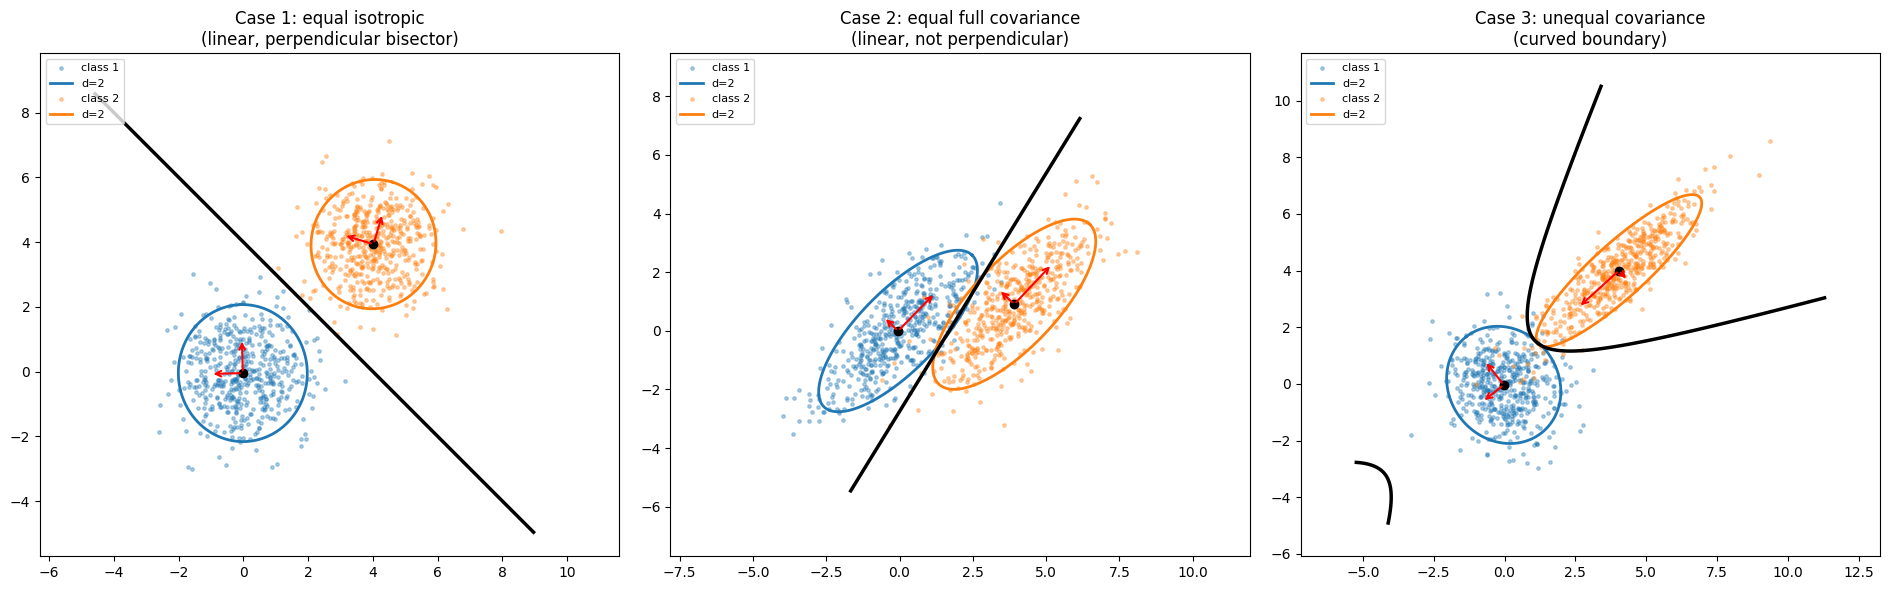

In [ ]:
def generate_class_data(mu, Sigma, n):
    mu = np.asarray(mu, dtype=float)
    d1 = gaussian_num(mu[0], 1.0, n)
    d2 = gaussian_num(mu[1], 1.0, n)
    Xb = np.column_stack([d1, d2])
    eigvals_S, eigvecs_S = np.linalg.eigh(Sigma)
    Sigma_half = eigvecs_S @ np.diag(np.sqrt(eigvals_S)) @ eigvecs_S.T
    return mu + (Xb - mu) @ Sigma_half.T

def gaussian_logpdf(X_grid, mu, Sigma):
    d = mu.shape[0]
    Sigma_inv = np.linalg.inv(Sigma)
    _, logdet = np.linalg.slogdet(Sigma)
    diff = X_grid - mu
    quad = np.einsum('ij,jk,ik->i', diff, Sigma_inv, diff)
    return -0.5 * logdet - 0.5 * d * np.log(2*np.pi) - 0.5 * quad

def plot_class_with_ellipse(ax, mu, Sigma, n, color, label, c=2):
    Y = generate_class_data(mu, Sigma, n)
    mu_hat = Y.mean(axis=0)
    cov_hat = np.cov(Y, rowvar=False)
    eigvals, eigvecs = np.linalg.eigh(cov_hat)
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    ax.scatter(Y[:, 0], Y[:, 1], s=6, alpha=0.35, color=color, label=label)
    curve = ellipse_points(mu_hat, eigvals, eigvecs, c=c)
    ax.plot(curve[0], curve[1], color=color, linewidth=2, label=f"d={c}")
    ax.plot(mu_hat[0], mu_hat[1], 'o', color='black', markersize=6)
    for i in range(2):
        length = np.sqrt(eigvals[i])
        vec = eigvecs[:, i] * length
        ax.annotate('', xy=mu_hat + vec, xytext=mu_hat,
                    arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
    return Y

def add_decision_boundary(ax, mu1, Sigma1, P1, Y1, mu2, Sigma2, P2, Y2):
    all_pts = np.vstack([Y1, Y2])
    pad = 2.0
    x_min, x_max = all_pts[:, 0].min() - pad, all_pts[:, 0].max() + pad
    y_min, y_max = all_pts[:, 1].min() - pad, all_pts[:, 1].max() + pad
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    grid = np.column_stack([xx.ravel(), yy.ravel()])

    g = (gaussian_logpdf(grid, np.asarray(mu1, dtype=float), Sigma1) + np.log(P1)
         - gaussian_logpdf(grid, np.asarray(mu2, dtype=float), Sigma2) - np.log(P2))
    g = g.reshape(xx.shape)
    ax.contour(xx, yy, g, levels=[0], colors='k', linewidths=2.5)

def plot_case(ax, mu1, Sigma1, mu2, Sigma2, title, n=500, c=2):
    Y1 = plot_class_with_ellipse(ax, mu1, Sigma1, n, 'tab:blue', 'class 1', c=c)
    Y2 = plot_class_with_ellipse(ax, mu2, Sigma2, n, 'tab:orange', 'class 2', c=c)
    add_decision_boundary(ax, mu1, Sigma1, 0.5, Y1, mu2, Sigma2, 0.5, Y2)
    ax.set_title(title)
    ax.axis('equal'); ax.legend(loc='upper left', fontsize=8)

fig, axes = plt.subplots(1, 3, figsize=(19, 6))

# Case 1: equal isotropic covariance 
plot_case(axes[0], [0, 0], 1.0*np.eye(2), [4, 4], 1.0*np.eye(2),
          "Case 1: equal isotropic\n(linear, perpendicular bisector)")

# Case 2: equal full covariance 
C_shared = np.array([[2.0, 1.5], [1.5, 2.0]])
plot_case(axes[1], [0, 0], C_shared, [4, 1], C_shared,
          "Case 2: equal full covariance\n(linear, not perpendicular)")

# Case 3: unequal covariance 
Sigma1_c3 = 1.0*np.eye(2)
Sigma2_c3 = np.array([[2.5, 2.0], [2.0, 2.0]])
plot_case(axes[2], [0, 0], Sigma1_c3, [4, 4], Sigma2_c3,
          "Case 3: unequal covariance\n(curved boundary)")

plt.tight_layout()
plt.show()